# RockNet v2 — Training Notebook
Two-stage multi-head rock classification: primary family head + conditional feature heads.

**Workflow:**
1. Mount Drive + clone repo
2. Load  → split → dataloaders
3. Warm-up primary head (epochs 0–4, secondary loss off)
4. Joint training (epochs 5+, full loss)
5. Temperature calibration on val set
6. Save checkpoint to Drive


## 0. Environment check

In [ ]:
import torch, sys
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
NVIDIA A100-SXM4-40GB, 40960 MiB, 40437 MiB


## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 2. Paths
Set  to wherever your capstone repo lives on Drive.

In [ ]:
from pathlib import Path

REPO_PATH     = Path("/content/drive/MyDrive/capstone")
MANIFEST_PATH = REPO_PATH / "ML-classifications/metadata/dataset_manifest.json"
WEIGHTS_OUT   = REPO_PATH / "ML-classifications/models/best_rocknet_v2.pt"

assert MANIFEST_PATH.exists(), f"Manifest not found: {MANIFEST_PATH}"
print("Manifest:", MANIFEST_PATH)


Manifest: /content/drive/MyDrive/capstone/ML-classifications/metadata/dataset_manifest.json


## 3. Install dependencies

In [ ]:
!pip install timm --quiet
import sys
sys.path.insert(0, str(REPO_PATH / "ML-classifications/scripts"))
from rocknet_v2 import (
    RockNetV2, FEATURE_SCHEMAS, LABELING_SCHEMAS, FAMILY_NAMES, FAMILY_TO_IDX,
    ROCK_FAMILIES, IGNORE_INDEX, SECONDARY_WARMUP_EPOCHS, LAMBDA_SECONDARY,
    label_to_idx, get_feature_value, get_feature_weight,
    compute_loss, save_checkpoint, load_checkpoint, train_tfms, val_tfms,
)
print("rocknet_v2 imported OK")

rocknet_v2 imported OK


## 4. Training configuration

In [ ]:
CFG = {
    # Data
    "min_reviewed":      True,    # if True, only use reviewed=True entries
    "use_auto_labeled":  True,    # also include auto_labeled entries (VLM-labeled, not human-confirmed)
    "source_weight":     True,    # weight sampler by entry.source_weight

    # Training
    "epochs":            60,
    "batch_size":        32,
    "lr":                3e-4,
    "weight_decay":      1e-4,
    "label_smoothing":   0.1,
    "grad_clip":         1.0,

    # Hard negative "other" class
    # Set to a folder of non-rock images, or None to skip
    "other_image_dir":   None,
    "other_max":         300,     # cap so "other" stays <=20% of training data

    # Checkpoint
    "patience":          10,      # early stopping on val primary accuracy
    "save_every":        5,       # also save a checkpoint every N epochs

    # New: phased fine-tuning
    "phase1_epochs":     SECONDARY_WARMUP_EPOCHS,  # 5
    "phase2_epochs":     7,                        # epochs 5..11
    "phase2_unfreeze_stages": [3],                # last ConvNeXt stage only
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Config:", CFG)

## 5. Dataset class

In [ ]:
import json, random
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

def _resolve_img_path(entry: dict) -> str | None:
    """Return the best available image path for an entry, or None if no file exists."""
    if other := entry.get("_other_path"):
        return other
    for key in ("processed_path", "raw_path"):
        p = entry.get(key)
        if p and Path(p).exists():
            return p
    return None

class RockDataset(Dataset):
    """
    Reads entries from dataset_manifest.json.

    Each item returns:
      (image_tensor, family_idx, feature_targets_dict, feature_weights_dict)

    feature_targets_dict: family → feat → scalar int64
      IGNORE_INDEX for entries from a different family or with n/a labels.

    feature_weights_dict: family → feat → scalar float32 in [0.5, 1.0]
      Derived from the labeler confidence rating stored in the manifest.
      1=uncertain→0.5, 2=likely→0.75, 3=certain→1.0.
      Old string-format entries and wrong-family slots default to 1.0.
    """
    def __init__(self, entries: list[dict], transform, include_other_dir=None, other_max: int = 300):
        self.transform = transform

        # Resolve and cache image paths once at init — avoids Path.exists() calls
        # on every __getitem__ (critical for Google Drive, which has high per-call latency).
        resolved = []
        for e in entries:
            p = _resolve_img_path(e)
            if p is not None:
                resolved.append((e, p))
        n_dropped = len(entries) - len(resolved)
        if n_dropped:
            print(f"  [RockDataset] dropped {n_dropped} entries with missing image files")

        self.entries    = [e for e, _ in resolved]
        self.img_paths  = [p for _, p in resolved]

        # Add hard-negative "other" class from a folder of non-rock images
        if include_other_dir and Path(include_other_dir).exists():
            exts = {".jpg", ".jpeg", ".png", ".webp"}
            other_paths = sorted([
                p for p in Path(include_other_dir).rglob("*") if p.suffix.lower() in exts
            ])
            random.shuffle(other_paths)
            other_paths = other_paths[:other_max]
            for p in other_paths:
                self.entries.append({"_other_path": str(p), "family": "other", "features": {}})
                self.img_paths.append(str(p))

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry    = self.entries[idx]
        img_path = self.img_paths[idx]

        img    = Image.open(img_path).convert("RGB")
        tensor = self.transform(img)

        family     = entry["family"]
        family_idx = FAMILY_TO_IDX.get(family, FAMILY_TO_IDX["other"])
        raw_feats  = entry.get("features", {})

        feat_targets = {}
        feat_weights = {}
        for fam in ROCK_FAMILIES:
            feat_targets[fam] = {}
            feat_weights[fam] = {}
            for feat, classes in LABELING_SCHEMAS[fam].items():
                if family != fam:
                    feat_targets[fam][feat] = torch.tensor(IGNORE_INDEX, dtype=torch.long)
                    feat_weights[fam][feat] = torch.tensor(1.0, dtype=torch.float32)
                else:
                    feat_entry = raw_feats.get(feat, "n/a")
                    feat_targets[fam][feat] = torch.tensor(
                        label_to_idx(feat, feat_entry, classes), dtype=torch.long
                    )
                    feat_weights[fam][feat] = torch.tensor(
                        get_feature_weight(feat_entry), dtype=torch.float32
                    )

        return tensor, torch.tensor(family_idx, dtype=torch.long), feat_targets, feat_weights


def collate_feat_targets(batch):
    """Custom collate: stack image tensors + family labels; concat feature target and weight dicts."""
    imgs, family_tgts, feat_tgts_list, feat_wts_list = zip(*batch)
    imgs        = torch.stack(imgs)
    family_tgts = torch.stack(family_tgts)
    feat_tgts = {
        fam: {
            feat: torch.stack([ft[fam][feat] for ft in feat_tgts_list])
            for feat in LABELING_SCHEMAS[fam]
        }
        for fam in ROCK_FAMILIES
    }
    feat_weights = {
        fam: {
            feat: torch.stack([fw[fam][feat] for fw in feat_wts_list])
            for feat in LABELING_SCHEMAS[fam]
        }
        for fam in ROCK_FAMILIES
    }
    return imgs, family_tgts, feat_tgts, feat_weights

print("Dataset class defined")

## 6. Load manifest and split
> Splits are **source-isolated** — each image source is an entirely separate photo collection,
> so no physical rock specimen can appear in more than one split.
>
> | Split | Sources | Purpose |
> |-------|---------|---------|
> | **Test** | `manual`, `astromaterials` | Final held-out eval (never seen during training) |
> | **Val** | `james_st_john` | Early stopping + temperature calibration |
> | **Train** | `lpi`, `smithsonian`, `flickr`, `kaggle` | Model training |

In [ ]:
import json, random
from collections import Counter, defaultdict
from pathlib import Path

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

# Rebase absolute paths from the dev machine to this environment's REPO_PATH.
def _rebase(p: str | None) -> str | None:
    if not p:
        return p
    parts = Path(p).parts
    try:
        idx = parts.index("capstone")
        return str(REPO_PATH / Path(*parts[idx + 1:]))
    except ValueError:
        return p

for e in manifest["images"]:
    e["processed_path"] = _rebase(e.get("processed_path"))
    e["raw_path"]       = _rebase(e.get("raw_path"))

all_entries = manifest["images"]

usable_statuses = {"reviewed"}
if CFG.get("use_auto_labeled", True):
    usable_statuses.add("auto_labeled")

all_entries = [
    e for e in all_entries
    if e.get("label_status") in usable_statuses
    and e.get("quality") != "rejected"
    and e.get("family") in ["basalt", "anorthosite", "breccia"]
]

print(f"Total usable entries: {len(all_entries)}")
print("By family:", dict(Counter(e["family"] for e in all_entries)))
print("By status:", dict(Counter(e.get("label_status") for e in all_entries)))
print("By source:", dict(Counter(e["source"] for e in all_entries)))

# ── Source-isolated splits ────────────────────────────────────────────────
# Each source is an entirely separate photo collection → zero specimen overlap
# between splits. No random seed, no percentage — fully deterministic.
#
# Val uses smithsonian + flickr: museum/close-up photos similar in domain
# to the training sources, covering all 3 families.
# james_st_john (field photography) is in training — its domain shift made
# val accuracy unreliable for early stopping.
#
# Test and val are explicitly named. Train is a catch-all so that any new
# sources added to the manifest automatically go to training rather than
# being silently dropped.
TEST_SOURCES = {"manual", "astromaterials"}   # held out, never seen during training
VAL_SOURCES  = {"smithsonian", "flickr"}      # early stopping + temperature calibration

HELD_OUT = TEST_SOURCES | VAL_SOURCES

test_entries  = [e for e in all_entries if e.get("source") in TEST_SOURCES]
val_entries   = [e for e in all_entries if e.get("source") in VAL_SOURCES]
train_entries = [e for e in all_entries if e.get("source") not in HELD_OUT]

assert len(TEST_SOURCES & VAL_SOURCES) == 0, "test/val source overlap!"

train_sources = sorted({e.get("source") for e in train_entries})
print(f"\nTrain sources: {train_sources}")

def split_summary(name, entries):
    by_fam = Counter(e["family"] for e in entries)
    by_src = Counter(e.get("source") for e in entries)
    print(f"\n{name} ({len(entries)} entries):")
    print(f"  families : {dict(by_fam)}")
    print(f"  sources  : {dict(by_src)}")
    for fam in ["basalt", "anorthosite", "breccia"]:
        assert by_fam.get(fam, 0) > 0, f"{name} has no {fam} images!"

split_summary("Train", train_entries)
split_summary("Val",   val_entries)
split_summary("Test",  test_entries)

total_assigned = len(train_entries) + len(val_entries) + len(test_entries)
assert total_assigned == len(all_entries), \
    f"BUG: {len(all_entries) - total_assigned} entries unassigned!"
print(f"\nAll {total_assigned} entries assigned ✓")

In [ ]:
# Save val and test splits as standalone manifests for auditability.
# These files record exactly which images were held out, reproducibly.
ML_ROOT = REPO_PATH / "ML-classifications"
for split_name, split_entries, split_sources in [
    ("val",  val_entries,  VAL_SOURCES),
    ("test", test_entries, TEST_SOURCES),
]:
    out = {
        "split":   split_name,
        "sources": sorted(split_sources),
        "images":  split_entries,
    }
    out_path = ML_ROOT / f"metadata/{split_name}_manifest.json"
    out_path.write_text(json.dumps(out, indent=2))
    print(f"Saved {len(split_entries)} entries → {out_path.name}")

## 7. Dataloaders

In [ ]:
print("Building datasets (checking image paths on Drive — may take a moment)...")
train_ds = RockDataset(
    train_entries, train_tfms,
    include_other_dir=CFG["other_image_dir"],
    other_max=CFG["other_max"],
)
val_ds  = RockDataset(val_entries,  val_tfms)
test_ds = RockDataset(test_entries, val_tfms)

print(f"\nUsable images — Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

# Verify all 3 families still present in each split after file-existence filter
from collections import Counter
for name, ds in [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]:
    fams = Counter(e["family"] for e in ds.entries if not e.get("_other_path"))
    print(f"  {name} families: {dict(fams)}")
    for fam in ["basalt", "anorthosite", "breccia"]:
        assert fams.get(fam, 0) > 0, f"{name} has no {fam} after filtering!"

# Weighted sampler: oversample by source_weight (boosts lunar sources)
def make_sampler(ds):
    weights = [e.get("source_weight", 1.0) for e in ds.entries]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"],
    sampler=make_sampler(train_ds) if CFG["source_weight"] else None,
    shuffle=(not CFG["source_weight"]),
    num_workers=2, pin_memory=True, collate_fn=collate_feat_targets,
)
val_loader = DataLoader(
    val_ds, batch_size=CFG["batch_size"],
    shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_feat_targets,
)
test_loader = DataLoader(
    test_ds, batch_size=CFG["batch_size"],
    shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_feat_targets,
)
print("Dataloaders ready")

## 8. Model

In [ ]:
model = RockNetV2().to(DEVICE)

# Count trainable parameters
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total/1e6:.1f}M  Trainable: {trainable/1e6:.1f}M")


Total params: 46.0M  Trainable: 46.0M


# 9. Optimizer and Scheduler (New)

In [ ]:
import re
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Matches both:
# backbone.stages.3....
# backbone.model.stages.3....
STAGE_RE = re.compile(r"^backbone\.(?:model\.)?stages\.(\d+)\.")

ALWAYS_TRAIN_PREFIXES = (
    "c3_reduce",
    "c4_reduce",
    "fuse_conv",
    "fuse_ln",
    "fuse_act",
    "gem",
    "gram",
    "primary_head",
    "family_heads",
)

def stage_idx_from_name(name):
    m = STAGE_RE.match(name)
    return int(m.group(1)) if m else None

def get_phase(epoch):
    if epoch < CFG["phase1_epochs"]:
        return 1
    if epoch < CFG["phase1_epochs"] + CFG["phase2_epochs"]:
        return 2
    return 3

def phase_length(phase):
    if phase == 1:
        return CFG["phase1_epochs"]
    if phase == 2:
        return CFG["phase2_epochs"]
    return CFG["epochs"] - CFG["phase1_epochs"] - CFG["phase2_epochs"]

def apply_phase_freezing(model, phase):
    # Freeze everything first
    for p in model.parameters():
        p.requires_grad = False

    # Always train the fusion/neck/pooling/heads
    for name, p in model.named_parameters():
        if name.startswith(ALWAYS_TRAIN_PREFIXES):
            p.requires_grad = True

    # Phase 2: unfreeze only the last ConvNeXt stage(s)
    if phase == 2:
        phase2_stages = set(CFG["phase2_unfreeze_stages"])
        for name, p in model.named_parameters():
            stage = stage_idx_from_name(name)
            if stage in phase2_stages:
                p.requires_grad = True

    # Phase 3: unfreeze the whole backbone
    elif phase == 3:
        for name, p in model.named_parameters():
            if name.startswith("backbone."):
                p.requires_grad = True

    # Keep calibration temperatures frozen during training
    model.primary_temp.requires_grad = False
    for fam_dict in model.feature_temps.values():
        for p in fam_dict.values():
            p.requires_grad = False

def split_trainable_params(model):
    head_params = []
    bb_top_params = []
    bb_low_params = []
    phase2_stages = set(CFG["phase2_unfreeze_stages"])

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        if not name.startswith("backbone."):
            head_params.append(p)
            continue

        stage = stage_idx_from_name(name)
        if stage in phase2_stages:
            bb_top_params.append(p)
        else:
            bb_low_params.append(p)

    return head_params, bb_top_params, bb_low_params

def build_optimizer_scheduler(model, phase):
    head_params, bb_top_params, bb_low_params = split_trainable_params(model)

    param_groups = []

    if phase == 1:
        # Heads only
        param_groups.append({
            "params": head_params,
            "lr": CFG["lr"],
        })

    elif phase == 2:
        # Last backbone stage + heads
        if bb_top_params:
            param_groups.append({
                "params": bb_top_params,
                "lr": CFG["lr"] * 0.1,
            })
        param_groups.append({
            "params": head_params,
            "lr": CFG["lr"],
        })

    else:
        # Full fine-tune
        if bb_low_params:
            param_groups.append({
                "params": bb_low_params,
                "lr": CFG["lr"] * 0.03,
            })
        if bb_top_params:
            param_groups.append({
                "params": bb_top_params,
                "lr": CFG["lr"] * 0.1,
            })
        param_groups.append({
            "params": head_params,
            "lr": CFG["lr"] * 0.5,
        })

    optimizer = AdamW(param_groups, weight_decay=CFG["weight_decay"])
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=max(1, phase_length(phase)),
        eta_min=1e-6,
    )
    return optimizer, scheduler

def print_trainable_summary(model, phase):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    head_params, bb_top_params, bb_low_params = split_trainable_params(model)

    print(f"Switched to phase {phase}")
    print(f"  Trainable params: {trainable/1e6:.2f}M / {total/1e6:.2f}M")
    print(f"  Head params:      {sum(p.numel() for p in head_params)/1e6:.2f}M")
    print(f"  Top backbone:     {sum(p.numel() for p in bb_top_params)/1e6:.2f}M")
    print(f"  Low backbone:     {sum(p.numel() for p in bb_low_params)/1e6:.2f}M")

In [ ]:
phase = None
optimizer = None
scheduler = None

print("Phase helpers ready")

## 10. Evaluation helper

In [ ]:
def evaluate(model, loader, epoch=999):
    model.eval()
    total_loss = 0.0
    correct_primary = 0
    total_samples   = 0

    from collections import defaultdict
    feat_correct = defaultdict(int)
    feat_total   = defaultdict(int)

    with torch.no_grad():
        for imgs, fam_tgts, feat_tgts, feat_wts in loader:
            imgs      = imgs.to(DEVICE)
            fam_tgts  = fam_tgts.to(DEVICE)
            feat_tgts = {fam: {f: t.to(DEVICE) for f, t in v.items()} for fam, v in feat_tgts.items()}
            feat_wts  = {fam: {f: w.to(DEVICE) for f, w in v.items()} for fam, v in feat_wts.items()}

            outputs = model(imgs)
            loss, _ = compute_loss(outputs, fam_tgts, feat_tgts, epoch=epoch, feat_weights=feat_wts)
            total_loss += loss.item() * len(imgs)

            preds = outputs["family_logits"].argmax(1)
            correct_primary += (preds == fam_tgts).sum().item()
            total_samples   += len(imgs)

            # Feature accuracy
            for fam in ROCK_FAMILIES:
                fam_idx  = FAMILY_TO_IDX[fam]
                fam_mask = fam_tgts == fam_idx
                if not fam_mask.any():
                    continue
                for feat, tgt in feat_tgts[fam].items():
                    valid = fam_mask & (tgt != IGNORE_INDEX)
                    if not valid.any():
                        continue
                    logits  = outputs["feature_logits"][fam][feat][valid]
                    correct = (logits.argmax(1) == tgt[valid]).sum().item()
                    feat_correct[f"{fam}.{feat}"] += correct
                    feat_total[f"{fam}.{feat}"]   += valid.sum().item()

    avg_loss    = total_loss / max(total_samples, 1)
    primary_acc = correct_primary / max(total_samples, 1)
    feat_acc    = {k: feat_correct[k] / max(feat_total[k], 1) for k in feat_total}

    return {"loss": avg_loss, "primary_acc": primary_acc, "feat_acc": feat_acc}

print("evaluate() defined")

evaluate() defined


# 11. Training loop (New)

In [ ]:
import time
from pathlib import Path
from tqdm import tqdm

best_val_acc   = 0.0
patience_count = 0
history        = []

WEIGHTS_OUT.parent.mkdir(parents=True, exist_ok=True)
CKPT_DIR = WEIGHTS_OUT.parent / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

phase = None
optimizer = None
scheduler = None

for epoch in range(CFG["epochs"]):
    new_phase = get_phase(epoch)

    # Reconfigure trainable params / optimizer / scheduler when phase changes.
    # Also reset patience so each phase gets a fair window — without this,
    # patience accumulated in phase 1/2 can fire early stopping before
    # phase 3 (full backbone fine-tune) has had any real epochs.
    if new_phase != phase:
        phase = new_phase
        apply_phase_freezing(model, phase)
        optimizer, scheduler = build_optimizer_scheduler(model, phase)
        print_trainable_summary(model, phase)
        patience_count = 0   # fresh patience window for each phase

    model.train()
    t0 = time.time()
    running = {"total": 0.0, "primary": 0.0, "secondary": 0.0}
    n_batches = 0

    for imgs, fam_tgts, feat_tgts, feat_wts in tqdm(train_loader, desc=f"Epoch {epoch}"):
        imgs = imgs.to(DEVICE)
        fam_tgts = fam_tgts.to(DEVICE)

        feat_tgts = {
            fam: {feat: t.to(DEVICE) for feat, t in fd.items()}
            for fam, fd in feat_tgts.items()
        }
        feat_wts = {
            fam: {feat: w.to(DEVICE) for feat, w in fd.items()}
            for fam, fd in feat_wts.items()
        }

        optimizer.zero_grad(set_to_none=True)

        outputs = model(imgs)
        loss, parts = compute_loss(
            outputs,
            fam_tgts,
            feat_tgts,
            epoch=epoch,
            label_smoothing=CFG["label_smoothing"],
            feat_weights=feat_wts,
        )

        loss.backward()

        trainable_params = [p for p in model.parameters() if p.requires_grad]
        torch.nn.utils.clip_grad_norm_(trainable_params, CFG["grad_clip"])

        optimizer.step()

        running["total"] += parts["total"]
        running["primary"] += parts["primary"]
        running["secondary"] += parts["secondary"]
        n_batches += 1

    scheduler.step()

    train_loss = running["total"] / max(n_batches, 1)

    val_metrics = evaluate(model, val_loader, epoch)
    val_acc = val_metrics["primary_acc"]
    elapsed = time.time() - t0

    current_lrs = scheduler.get_last_lr()

    row = {
        "epoch": epoch,
        "phase": phase,
        "train_loss": round(train_loss, 4),
        "val_loss": round(val_metrics["loss"], 4),
        "val_acc": round(val_acc, 4),
        "secondary": round(running["secondary"] / max(n_batches, 1), 4),
        "lrs": [round(x, 8) for x in current_lrs],
        "elapsed_s": round(elapsed, 1),
    }

    for k, v in val_metrics["feat_acc"].items():
        row[k] = None if v is None else round(v, 4)

    history.append(row)

    improved = val_acc > best_val_acc
    flag = " *BEST*" if improved else ""

    lr_str = ",".join(f"{x:.1e}" for x in current_lrs)
    print(
        f"Epoch {epoch:3d} | phase={phase} | "
        f"train={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_acc:.3f} | lrs=[{lr_str}] | {elapsed:.0f}s{flag}"
    )

    if improved:
        best_val_acc = val_acc
        patience_count = 0
        save_checkpoint(
            model,
            WEIGHTS_OUT,
            metadata={"cfg": CFG, "epoch": epoch, "best_val_acc": best_val_acc},
        )
    else:
        patience_count += 1

    if (epoch + 1) % CFG["save_every"] == 0:
        save_checkpoint(
            model,
            CKPT_DIR / f"rocknet_v2_epoch{epoch:03d}.pth",
            metadata={"cfg": CFG, "epoch": epoch, "val_acc": val_acc},
        )

    if patience_count >= CFG["patience"]:
        print(f"Early stopping at epoch {epoch} (no improvement for {CFG['patience']} epochs)")
        break

import pandas as pd
history_df = pd.DataFrame(history)
display(history_df.tail())

print(f"Best validation primary accuracy: {best_val_acc:.4f}")
print(f"Best checkpoint saved to: {WEIGHTS_OUT}")

## 12. Feature accuracy (val)

In [ ]:
best_model, _ = load_checkpoint(WEIGHTS_OUT, DEVICE)

val_m = evaluate(best_model, val_loader)
print(f"Val primary acc: {val_m['primary_acc']:.4f}")
print("\nFeature accuracies (val):")
for k in sorted(val_m["feat_acc"]):
    print(f"  {k:<40} {val_m['feat_acc'][k]:.3f}")

Val primary acc: 0.9678

Feature accuracies (val):
  anorthosite.brightness                   0.855
  anorthosite.crystal_fabric               0.867
  anorthosite.mafic_content_hint           0.855
  anorthosite.surface_character            0.877
  basalt.groundmass_texture                0.792
  basalt.luster                            0.913
  basalt.phenocryst_hint                   0.924
  basalt.vesicularity                      0.721
  breccia.clast_angularity                 0.790
  breccia.sorting                          0.827
  breccia.support_fabric                   0.936


## 13. Temperature calibration
Fits a separate temperature scalar per head on the validation set.

In [ ]:
import torch.optim as optim_

def calibrate_temperature(model, loader, n_epochs=50, lr=0.01):
    """Fit temperature scalars on val set. Freeze all other params."""
    model.eval()

    # Enable grad only on temperature params
    for p in model.parameters():
        p.requires_grad_(False)
    model.primary_temp.requires_grad_(True)
    for fam in ROCK_FAMILIES:
        for feat in model.feature_temps[fam]:
            model.feature_temps[fam][feat].requires_grad_(True)

    temp_params = (
        [model.primary_temp]
        + [model.feature_temps[fam][feat] for fam in ROCK_FAMILIES for feat in model.feature_temps[fam]]
    )
    cal_opt = optim_.LBFGS(temp_params, lr=lr, max_iter=50)

    # Collect all logits + targets first (val set is small)
    all_fam_logits  = []
    all_fam_tgts    = []
    all_feat_logits = {fam: {f: [] for f in FEATURE_SCHEMAS[fam]} for fam in ROCK_FAMILIES}
    all_feat_tgts   = {fam: {f: [] for f in FEATURE_SCHEMAS[fam]} for fam in ROCK_FAMILIES}

    with torch.no_grad():
        for imgs, fam_tgts, feat_tgts, feat_wts in loader:
            imgs      = imgs.to(DEVICE)
            fam_tgts  = fam_tgts.to(DEVICE)
            feat_tgts = {fam: {f: t.to(DEVICE) for f, t in v.items()} for fam, v in feat_tgts.items()}
            out       = model(imgs)
            all_fam_logits.append(out["family_logits"])
            all_fam_tgts.append(fam_tgts)
            for fam in ROCK_FAMILIES:
                for feat in FEATURE_SCHEMAS[fam]:
                    all_feat_logits[fam][feat].append(out["feature_logits"][fam][feat])
                    all_feat_tgts[fam][feat].append(feat_tgts[fam][feat])

    all_fam_logits = torch.cat(all_fam_logits)
    all_fam_tgts   = torch.cat(all_fam_tgts)
    for fam in ROCK_FAMILIES:
        for feat in FEATURE_SCHEMAS[fam]:
            all_feat_logits[fam][feat] = torch.cat(all_feat_logits[fam][feat])
            all_feat_tgts[fam][feat]   = torch.cat(all_feat_tgts[fam][feat])

    def nll():
        cal_opt.zero_grad()
        loss = torch.nn.functional.cross_entropy(
            all_fam_logits / model.primary_temp.clamp(min=0.1), all_fam_tgts
        )
        for fam in ROCK_FAMILIES:
            fam_idx  = FAMILY_TO_IDX[fam]
            fam_mask = all_fam_tgts == fam_idx
            for feat in FEATURE_SCHEMAS[fam]:
                tgt   = all_feat_tgts[fam][feat]
                valid = fam_mask & (tgt != IGNORE_INDEX)
                if valid.any():
                    temp = model.feature_temps[fam][feat].clamp(min=0.1)
                    loss = loss + torch.nn.functional.cross_entropy(
                        all_feat_logits[fam][feat][valid] / temp, tgt[valid]
                    )
        loss.backward()
        return loss

    for _ in range(n_epochs):
        cal_opt.step(nll)

    print(f"Primary temp: {model.primary_temp.item():.4f}")
    for fam in ROCK_FAMILIES:
        for feat in model.feature_temps[fam]:
            print(f"  {fam}.{feat}: {model.feature_temps[fam][feat].item():.4f}")

    # Freeze temps again
    for p in model.parameters():
        p.requires_grad_(True)
    model.primary_temp.requires_grad_(False)
    for fam in ROCK_FAMILIES:
        for feat in model.feature_temps[fam]:
            model.feature_temps[fam][feat].requires_grad_(False)

    return model

best_model = calibrate_temperature(best_model, val_loader)
save_checkpoint(best_model, WEIGHTS_OUT, metadata={"calibrated": True})
print("Calibrated checkpoint saved.")

Primary temp: 0.7115
  basalt.groundmass_texture: 1.8499
  basalt.luster: 1.2110
  basalt.phenocryst_hint: 1.5536
  basalt.vesicularity: 1.5161
  anorthosite.brightness: 1.6107
  anorthosite.crystal_fabric: 2.6701
  anorthosite.mafic_content_hint: 2.5435
  anorthosite.surface_character: 1.9233
  breccia.clast_angularity: 2.6942
  breccia.sorting: 2.4608
  breccia.support_fabric: 2.0174
Calibrated checkpoint saved.


## 14. Final test evaluation

In [ ]:
test_m = evaluate(best_model, test_loader)
print(f"Test primary accuracy: {test_m['primary_acc']:.4f}")
print("Test feature accuracies:")
for k in sorted(test_m["feat_acc"]):
    print(f"  {k:<40} {test_m['feat_acc'][k]:.3f}")

## 14b. Confusion matrix & classification report

              precision    recall  f1-score   support

      basalt       0.95      0.96      0.95       185
 anorthosite       0.97      0.97      0.97        76
     breccia       0.91      0.90      0.91        81

    accuracy                           0.95       342
   macro avg       0.95      0.94      0.94       342
weighted avg       0.95      0.95      0.95       342



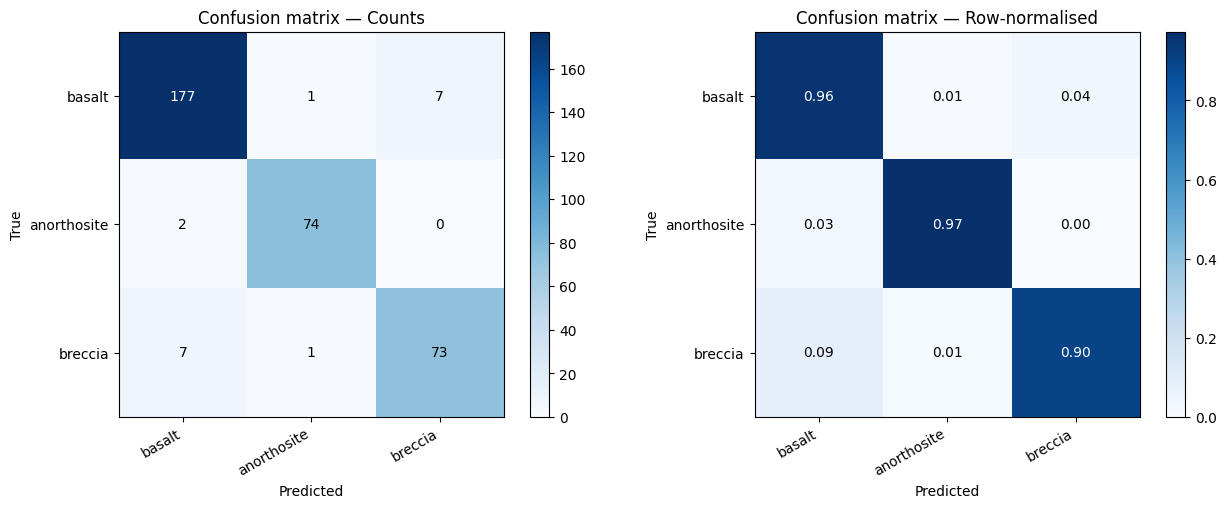

Saved → confusion_matrix.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import classification_report, confusion_matrix

best_model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for imgs, fam_tgts, _, __ in test_loader:
        imgs = imgs.to(DEVICE)
        out  = best_model(imgs)
        preds = out["family_logits"].argmax(1).cpu()
        all_preds.append(preds)
        all_targets.append(fam_tgts)

all_preds   = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

# Only show rock classes (exclude 'other' if not present in test set)
present = sorted(set(all_targets))
labels  = [FAMILY_NAMES[i] for i in present]

# ── Classification report ─────────────────────────────────────────────
print(classification_report(all_targets, all_preds, labels=present, target_names=labels))

# ── Confusion matrix ──────────────────────────────────────────────────
cm      = confusion_matrix(all_targets, all_preds, labels=present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, fmt, title in [
    (axes[0], cm,      "d",    "Counts"),
    (axes[1], cm_norm, ".2f",  "Row-normalised"),
]:
    im = ax.imshow(data, interpolation="nearest", cmap="Blues")
    fig.colorbar(im, ax=ax)
    ax.set(xticks=range(len(labels)), yticks=range(len(labels)),
           xticklabels=labels, yticklabels=labels,
           xlabel="Predicted", ylabel="True", title=f"Confusion matrix — {title}")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    thresh = data.max() / 2.0
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, format(data[i, j], fmt),
                    ha="center", va="center",
                    color="white" if data[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig(str(WEIGHTS_OUT.parent / "confusion_matrix.png"), dpi=150)
plt.show()
print("Saved → confusion_matrix.png")


## 15. Training curves

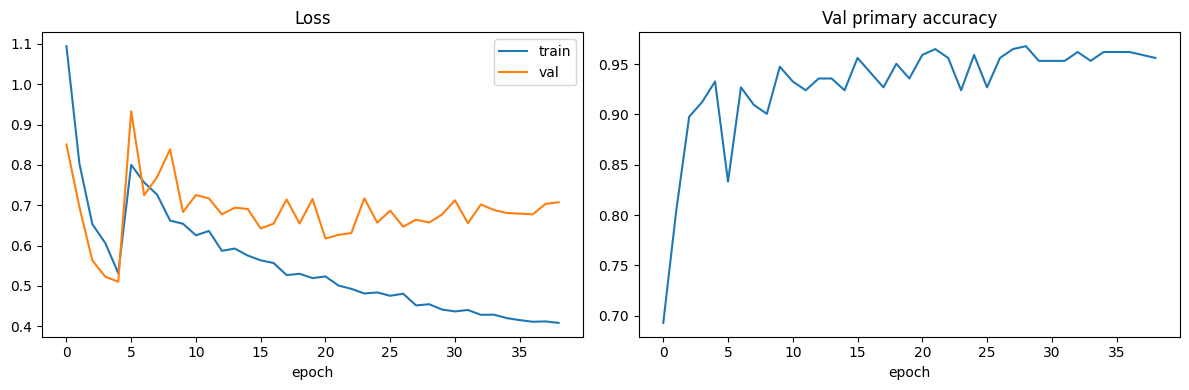

In [ ]:
import matplotlib.pyplot as plt

epochs_  = [r["epoch"] for r in history]
tr_loss  = [r["train_loss"] for r in history]
va_loss  = [r["val_loss"] for r in history]
va_acc   = [r["val_acc"] for r in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_, tr_loss, label="train"); axes[0].plot(epochs_, va_loss, label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("epoch")
axes[1].plot(epochs_, va_acc); axes[1].set_title("Val primary accuracy"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.savefig(str(WEIGHTS_OUT.parent / "training_curves.png"), dpi=120)
plt.show()
